# Results & Ablation Study

This notebook rebuilds the Section 4 analysis from the standalone artifacts produced by `run_two_gpu_lr_sweep.sh`.

By default it reads from `outputs_new_final_v2`, but you can change `OUTPUT_DIR` in the configuration cell if your latest sweep lives somewhere else.


In [ ]:
import json
import math
from pathlib import Path

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None

try:
    import pandas as pd
except ImportError:
    pd = None

if plt is not None:
    plt.style.use('seaborn-v0_8-whitegrid')


In [ ]:
OUTPUT_DIR = Path('outputs_new_final_clean')
PUBLISHED_SOTA = 0.61
GPT4O_THREE_SHOT = 0.44

CORE_ABLATION_ORDER = [
    ('BiLSTM-CRF', 'bilstm_crf'),
    ('DeBERTa Baseline', 'deberta_baseline'),
    ('+ Focal Loss', 'deberta_focal'),
    ('+ Definition Prompting', 'deberta_definition'),
    ('+ Multi-task', 'deberta_multitask'),
    ('+ Synthetic + Curriculum', 'deberta_synthetic_curriculum'),
    ('Combined w/o Synthetic', 'deberta_combined_no_synth'),
    ('Combined', 'deberta_combined'),
    ('Hierarchical Pipeline', 'hierarchical_deberta'),
    ('Hierarchical Pipeline (0.1 no-impact)', 'hierarchical_deberta_0.1_no_impact'),
]

ADVANCED_ORDER = [
    ('Recall Boost (seed 42)', 'recall_boost_ow02_s42'),
    ('Recall Boost (seed 123)', 'recall_boost_ow02_s123'),
    ('R-Drop (seed 42)', 'rdrop_a1_s42'),
    ('R-Drop (seed 123)', 'rdrop_a1_s123'),
    ('FGM + SWA (seed 42)', 'fgm05_swa_s42'),
]

COLOR_MAP = {
    'bilstm_crf': '#9E9E9E',
    'deberta_baseline': '#2196F3',
    'deberta_focal': '#4CAF50',
    'deberta_definition': '#66BB6A',
    'deberta_multitask': '#43A047',
    'deberta_synthetic_curriculum': '#26A69A',
    'deberta_combined_no_synth': '#FFB74D',
    'deberta_combined': '#FB8C00',
    'hierarchical_deberta': '#00897B',
    'hierarchical_deberta_0.1_no_impact': '#00695C',
    'recall_boost_ow02_s42': '#8E24AA',
    'recall_boost_ow02_s123': '#AB47BC',
    'rdrop_a1_s42': '#E53935',
    'rdrop_a1_s123': '#EF5350',
    'fgm05_swa_s42': '#5E35B1',
    'ensemble_size_2': '#1565C0',
    'ensemble_size_3': '#2E7D32',
    'ensemble_size_4': '#EF6C00',
    'ensemble_size_5': '#6A1B9A',
}

assert OUTPUT_DIR.exists(), f'Missing output directory: {OUTPUT_DIR.resolve()}'
print(f'Using artifacts from: {OUTPUT_DIR.resolve()}')


Using artifacts from: /home/ismail/Documents/NLP_assignment/outputs_new_final_v2


In [ ]:
def read_json(path):
    with path.open('r', encoding='utf-8') as handle:
        return json.load(handle)


def safe_float(value, default=float('nan')):
    try:
        return float(value)
    except (TypeError, ValueError):
        return default


def format_lr(value):
    if value is None or (isinstance(value, float) and not math.isfinite(value)):
        return 'n/a'
    return f'{value:.0e}' if value < 0.001 else f'{value:g}'


def display_rows(rows, columns=None, sort_by=None, ascending=False, max_rows=None):
    working = list(rows)
    if sort_by is not None:
        working.sort(key=lambda row: row.get(sort_by, float('-inf')), reverse=not ascending)
    if max_rows is not None:
        working = working[:max_rows]

    if pd is not None:
        df = pd.DataFrame(working)
        if columns is not None:
            existing = [col for col in columns if col in df.columns]
            df = df[existing]
        display(df.reset_index(drop=True))
        return df

    for row in working:
        if columns is not None:
            row = {column: row.get(column) for column in columns}
        print(row)
    return working


def summarize_log(path):
    entries = read_json(path)
    if not isinstance(entries, list) or not entries:
        return None, []

    experiment_name = path.stem[:-4] if path.stem.endswith('_log') else path.stem
    family = experiment_name.split('_lr', 1)[0] if '_lr' in experiment_name else experiment_name
    best_f1_entry = max(entries, key=lambda row: row.get('relaxed_f1', float('-inf')))
    valid_dev_loss = [row for row in entries if math.isfinite(safe_float(row.get('dev_loss')))]
    best_loss_entry = min(valid_dev_loss, key=lambda row: safe_float(row.get('dev_loss'))) if valid_dev_loss else None

    return {
        'experiment_name': experiment_name,
        'family': family,
        'epochs_completed': len(entries),
        'best_relaxed_f1': safe_float(best_f1_entry.get('relaxed_f1')),
        'best_strict_f1': safe_float(best_f1_entry.get('strict_f1')),
        'best_epoch_by_f1': best_f1_entry.get('epoch'),
        'best_dev_loss': safe_float(best_loss_entry.get('dev_loss')) if best_loss_entry else float('nan'),
        'best_epoch_by_loss': best_loss_entry.get('epoch') if best_loss_entry else None,
        'final_relaxed_f1': safe_float(entries[-1].get('relaxed_f1')),
        'final_dev_loss': safe_float(entries[-1].get('dev_loss')),
    }, entries


def load_log_artifacts(output_dir):
    summaries = []
    logs_by_experiment = {}
    for path in sorted(output_dir.glob('*_log.json')):
        summary, entries = summarize_log(path)
        if summary is not None:
            summaries.append(summary)
            logs_by_experiment[summary['experiment_name']] = entries
    return summaries, logs_by_experiment


def load_sweep_rows(output_dir):
    rows = []
    for path in sorted(output_dir.glob('*_lr_sweep.json')):
        data = read_json(path)
        family = data.get('experiment_name', path.stem.replace('_lr_sweep', ''))
        for run in data.get('runs', []):
            best_relaxed_f1 = safe_float(run.get('best_dev_f1', run.get('relaxed_f1')))
            rows.append({
                'family': family,
                'experiment_name': run.get('experiment_name'),
                'lr': run.get('lr'),
                'lr_display': format_lr(run.get('lr')),
                'sweep_best_dev_f1': safe_float(run.get('best_dev_f1')),
                'best_relaxed_f1': best_relaxed_f1,
                'best_strict_f1': safe_float(run.get('strict_f1')),
                'relaxed_precision': safe_float(run.get('relaxed_precision')),
                'relaxed_recall': safe_float(run.get('relaxed_recall')),
                'num_logged_epochs': run.get('num_logged_epochs'),
            })
    return rows


def load_topk_rows(output_dir):
    topk = {}
    for path in sorted((output_dir / 'checkpoints').glob('*/topk_summary.json')):
        data = read_json(path)
        checkpoints = data.get('checkpoints', [])
        topk[data.get('experiment_name', path.parent.name)] = {
            'topk_saved': len(checkpoints),
            'top_checkpoint_path': checkpoints[0]['path'] if checkpoints else None,
        }
    return topk


def load_model_soup_rows(output_dir):
    soup_rows = []
    best_soup_by_model_type = {}
    for path in sorted(output_dir.glob('*_soup_results.json')):
        data = read_json(path)
        if not isinstance(data, dict):
            continue
        experiment_name = data.get('experiment_name', path.stem.replace('_results', ''))
        source_details = data.get('source_experiments', [])
        source_names = [detail.get('source_experiment') for detail in source_details if detail.get('source_experiment')]
        row = {
            'experiment_name': experiment_name,
            'family': experiment_name.replace('_soup', ''),
            'display_name': experiment_name,
            'model_type': data.get('model_type', data.get('metadata', {}).get('model_type', 'unknown')),
            'best_relaxed_f1': safe_float(data.get('relaxed_f1')),
            'best_strict_f1': safe_float(data.get('strict_f1')),
            'relaxed_precision': safe_float(data.get('relaxed_precision')),
            'relaxed_recall': safe_float(data.get('relaxed_recall')),
            'num_checkpoints': len(data.get('checkpoint_paths', [])),
            'num_source_experiments': len(source_details),
            'source_experiments': ', '.join(source_names),
            'saved_model_path': data.get('saved_model_path'),
        }
        soup_rows.append(row)

        model_type = row['model_type']
        current = best_soup_by_model_type.get(model_type)
        if current is None or row['best_relaxed_f1'] > current['best_relaxed_f1']:
            best_soup_by_model_type[model_type] = row

    soup_rows.sort(key=lambda row: row.get('best_relaxed_f1', float('-inf')), reverse=True)
    best_rows = sorted(best_soup_by_model_type.values(), key=lambda row: row.get('best_relaxed_f1', float('-inf')), reverse=True)
    return soup_rows, best_rows


def load_ensemble_search_rows(output_dir):
    ensemble_rows = []
    best_by_size_rows = []
    grouped_candidates = {}
    for path in sorted(output_dir.glob('*_results.json')):
        data = read_json(path)
        if not isinstance(data, dict):
            continue
        if 'best_overall' not in data or 'best_by_size' not in data:
            continue

        experiment_name = data.get('experiment_name', path.stem.replace('_results', ''))
        best_overall = data.get('best_overall', {})
        ensemble_rows.append({
            'experiment_name': experiment_name,
            'vote_method': data.get('vote_method', 'unknown'),
            'candidate_count': data.get('candidate_count'),
            'total_combinations': data.get('search_space', {}).get('total_combinations'),
            'best_overall_relaxed_f1': safe_float(best_overall.get('relaxed_f1')),
            'best_overall_strict_f1': safe_float(best_overall.get('strict_f1')),
            'best_overall_models': ', '.join(best_overall.get('models', [])),
            'combination_results_dir': data.get('combination_results_dir'),
        })

        for size, record in sorted(data.get('best_by_size', {}).items(), key=lambda item: int(item[0])):
            size_num = int(size)
            best_by_size_rows.append({
                'ensemble_experiment_name': experiment_name,
                'family': f'ensemble_size_{size_num}',
                'display_name': f'{size_num} models',
                'num_models': size_num,
                'vote_method': data.get('vote_method', 'unknown'),
                'best_relaxed_f1': safe_float(record.get('relaxed_f1')),
                'best_strict_f1': safe_float(record.get('strict_f1')),
                'relaxed_precision': safe_float(record.get('relaxed_precision')),
                'relaxed_recall': safe_float(record.get('relaxed_recall')),
                'ci_lower': safe_float(record.get('ci_lower')),
                'ci_upper': safe_float(record.get('ci_upper')),
                'annotation_label': data.get('vote_method', 'unknown'),
                'models': ', '.join(record.get('models', [])),
            })

        for record in data.get('all_results', []):
            size_num = int(record.get('num_models', 0))
            vote_method = data.get('vote_method', record.get('vote_method', 'unknown'))
            group_key = (vote_method, size_num)
            grouped_candidates.setdefault(group_key, []).append({
                'ensemble_experiment_name': experiment_name,
                'family': f'ensemble_size_{size_num}',
                'num_models': size_num,
                'vote_method': vote_method,
                'best_relaxed_f1': safe_float(record.get('relaxed_f1')),
                'best_strict_f1': safe_float(record.get('strict_f1')),
                'relaxed_precision': safe_float(record.get('relaxed_precision')),
                'relaxed_recall': safe_float(record.get('relaxed_recall')),
                'models': ', '.join(record.get('models', [])),
            })

    ensemble_rows.sort(key=lambda row: row.get('best_overall_relaxed_f1', float('-inf')), reverse=True)
    best_by_size_rows.sort(key=lambda row: (row['ensemble_experiment_name'], row['num_models']))

    top_two_per_group_rows = []
    for (vote_method, size_num), rows in sorted(grouped_candidates.items(), key=lambda item: (item[0][0], item[0][1])):
        ranked = sorted(rows, key=lambda row: row.get('best_relaxed_f1', float('-inf')), reverse=True)[:2]
        for rank_index, row in enumerate(ranked, start=1):
            top_row = dict(row)
            top_row['rank_within_group'] = rank_index
            top_row['display_name'] = f"{size_num} models #{rank_index}"
            top_row['annotation_label'] = vote_method
            top_two_per_group_rows.append(top_row)

    return ensemble_rows, best_by_size_rows, top_two_per_group_rows


def merge_run_rows(output_dir):
    log_rows, logs_by_experiment = load_log_artifacts(output_dir)
    sweep_rows = load_sweep_rows(output_dir)
    topk_rows = load_topk_rows(output_dir)
    logs_by_name = {row['experiment_name']: row for row in log_rows}

    merged = []
    for sweep in sweep_rows:
        row = dict(sweep)
        row.update(logs_by_name.get(sweep['experiment_name'], {}))
        row.update(topk_rows.get(sweep['experiment_name'], {}))
        merged.append(row)
    return merged, logs_by_experiment, log_rows, sweep_rows, topk_rows


def score_value(row, metric_key='best_relaxed_f1'):
    return row.get(metric_key, row.get('sweep_best_dev_f1', float('-inf')))


def sort_rows_by_metric(rows, metric_key='best_relaxed_f1'):
    return sorted(rows, key=lambda row: score_value(row, metric_key), reverse=True)


def best_by_group(rows, group_key, metric_key='best_relaxed_f1'):
    grouped = {}
    for row in rows:
        group = row[group_key]
        current = grouped.get(group)
        if current is None or score_value(row, metric_key) > score_value(current, metric_key):
            grouped[group] = row
    return list(grouped.values())


def best_by_family(run_rows, metric_key='best_relaxed_f1'):
    return best_by_group(run_rows, 'family', metric_key=metric_key)


def pick_rows(best_rows, ordered_families):
    by_family = {row['family']: row for row in best_rows}
    picked = []
    for display_name, family in ordered_families:
        if family in by_family:
            row = dict(by_family[family])
            row['display_name'] = display_name
            picked.append(row)
    return picked


def plot_barh(rows, title, subtitle=None, add_reference_lines=True):
    if plt is None:
        print('matplotlib is not installed; skipping plot.')
        return
    if not rows:
        print('No rows available for plotting.')
        return

    labels = [row['display_name'] for row in rows]
    scores = [row.get('best_relaxed_f1', row.get('sweep_best_dev_f1', float('nan'))) for row in rows]
    colors = [COLOR_MAP.get(row['family'], '#2196F3') for row in rows]

    fig, ax = plt.subplots(figsize=(12, max(4, 0.6 * len(rows))))
    bars = ax.barh(labels, scores, color=colors)

    if add_reference_lines:
        ax.axvline(PUBLISHED_SOTA, color='red', linestyle='--', linewidth=2, label=f'Published SOTA ({PUBLISHED_SOTA:.2f})')
        ax.axvline(GPT4O_THREE_SHOT, color='gray', linestyle=':', linewidth=1.5, label=f'GPT-4o 3-shot ({GPT4O_THREE_SHOT:.2f})')

    for bar, row in zip(bars, rows):
        score = row.get('best_relaxed_f1', row.get('sweep_best_dev_f1', float('nan')))
        annotation = row.get('annotation_label')
        if annotation is None:
            lr_display = row.get('lr_display')
            annotation = f' @ {lr_display}' if lr_display else ''
        ax.text(
            bar.get_width() + 0.005,
            bar.get_y() + bar.get_height() / 2,
            f"{score:.3f}{annotation}",
            va='center',
            fontsize=10,
            fontweight='bold',
        )

    ax.set_xlabel('Relaxed F1')
    ax.set_title(title if subtitle is None else f'{title}\n{subtitle}')
    ax.set_xlim(0, max(max(scores) + 0.08, 0.65))
    ax.invert_yaxis()
    if add_reference_lines:
        ax.legend(loc='lower right')
    plt.tight_layout()
    plt.show()


def plot_learning_curves(best_rows, logs_by_experiment, families, title):
    if plt is None:
        print('matplotlib is not installed; skipping plot.')
        return
    selected = [row for row in best_rows if row['family'] in families]
    if not selected:
        print('No matching runs found.')
        return

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for row in selected:
        entries = logs_by_experiment.get(row['experiment_name'], [])
        if not entries:
            continue
        epochs = [entry['epoch'] for entry in entries]
        relaxed_f1 = [safe_float(entry.get('relaxed_f1')) for entry in entries]
        dev_loss = [safe_float(entry.get('dev_loss')) for entry in entries]
        label = f"{row['family']} ({row['lr_display']})"
        axes[0].plot(epochs, relaxed_f1, marker='o', label=label)
        axes[1].plot(epochs, dev_loss, marker='o', label=label)

    axes[0].set_title('Dev Relaxed F1 by Epoch')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Relaxed F1')
    axes[1].set_title('Validation Loss by Epoch')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Dev Loss')
    axes[0].legend(loc='lower right', fontsize=9)
    axes[1].legend(loc='upper right', fontsize=9)
    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


## Load Sweep Artifacts

This section reads the learning-rate sweep summaries, per-epoch training logs, and saved top-k checkpoint metadata from the selected output directory.


In [ ]:
run_rows, logs_by_experiment, log_rows, sweep_rows, topk_rows = merge_run_rows(OUTPUT_DIR)
soup_rows, best_soup_rows = load_model_soup_rows(OUTPUT_DIR)
ensemble_rows, ensemble_best_by_size_rows, ensemble_top_two_rows = load_ensemble_search_rows(OUTPUT_DIR)
best_rows = best_by_family(run_rows)
best_rows_strict = best_by_family(run_rows, metric_key='best_strict_f1')
best_soup_rows_strict = best_by_group(soup_rows, 'model_type', metric_key='best_strict_f1')
ensemble_rows_relaxed = sort_rows_by_metric(ensemble_rows, 'best_overall_relaxed_f1')
ensemble_rows_strict = sort_rows_by_metric(ensemble_rows, 'best_overall_strict_f1')

sweep_summary_files = len(list(OUTPUT_DIR.glob('*_lr_sweep.json')))
log_files = len(list(OUTPUT_DIR.glob('*_log.json')))
topk_summary_files = len(list((OUTPUT_DIR / 'checkpoints').glob('*/topk_summary.json')))

overview = [
    {'artifact': 'LR sweep summary files', 'count': sweep_summary_files},
    {'artifact': 'Concrete sweep runs', 'count': len(run_rows)},
    {'artifact': 'Per-run training logs', 'count': log_files},
    {'artifact': 'Top-k checkpoint summaries', 'count': topk_summary_files},
    {'artifact': 'Model soup result files', 'count': len(soup_rows)},
    {'artifact': 'Ensemble search result files', 'count': len(ensemble_rows)},
    {'artifact': 'Best run families available', 'count': len(best_rows)},
]
display_rows(overview, columns=['artifact', 'count'])
print('Families found:', ', '.join(sorted(row['family'] for row in best_rows)))


,artifact,count
0,LR sweep summary files,16
1,Concrete sweep runs,46
2,Per-run training logs,53
3,Top-k checkpoint summaries,55
4,Model soup result files,36
5,Ensemble search result files,3
6,Best run families available,16


Families found: bilstm_crf, deberta_baseline, deberta_combined, deberta_combined_no_synth, deberta_definition, deberta_focal, deberta_multitask, deberta_synthetic_curriculum, fgm05_swa_s42, gliner_finetune, hierarchical_deberta, hierarchical_deberta_0.1_no_impact, rdrop_a1_s123, rdrop_a1_s42, recall_boost_ow02_s123, recall_boost_ow02_s42


## Full LR Sweep Table

Each row below is one concrete training run from `run_two_gpu_lr_sweep.sh`, merged with its best epoch, best relaxed F1, validation loss summary, and top-k checkpoint inventory.


In [ ]:
print('Top runs sorted by relaxed F1:')
display_rows(
    sort_rows_by_metric(run_rows, 'best_relaxed_f1'),
    columns=[
        'family',
        'experiment_name',
        'lr_display',
        'best_relaxed_f1',
        'best_strict_f1',
        'best_epoch_by_f1',
        'best_dev_loss',
        'best_epoch_by_loss',
        'epochs_completed',
        'topk_saved',
    ],
    max_rows=30,
)

print('\nTop runs sorted by strict F1:')
display_rows(
    sort_rows_by_metric(run_rows, 'best_strict_f1'),
    columns=[
        'family',
        'experiment_name',
        'lr_display',
        'best_relaxed_f1',
        'best_strict_f1',
        'best_epoch_by_f1',
        'best_dev_loss',
        'best_epoch_by_loss',
        'epochs_completed',
        'topk_saved',
    ],
    max_rows=30,
)


Top runs sorted by relaxed F1:


,family,experiment_name,lr_display,best_relaxed_f1,best_strict_f1,best_epoch_by_f1,best_dev_loss,best_epoch_by_loss,epochs_completed,topk_saved
0,hierarchical_deberta,hierarchical_deberta_lr2em05,2e-05,0.604,0.371747,NaN,NaN,NaN,NaN,NaN
1,deberta_baseline,deberta_baseline_lr2em05,2e-05,0.595,0.408759,8.0,0.230109,5.0,10.0,5.0
2,recall_boost_ow02_s42,recall_boost_ow02_s42_lr2em05,2e-05,0.582,0.311864,8.0,0.205525,3.0,8.0,5.0
3,deberta_multitask,deberta_multitask_lr5em05,5e-05,0.581,0.381625,7.0,0.211397,4.0,9.0,5.0
4,rdrop_a1_s42,rdrop_a1_s42_lr2em05,2e-05,0.577,0.337662,8.0,0.210030,6.0,11.0,5.0
5,deberta_definition,deberta_definition_lr2em05,2e-05,0.575,0.350168,8.0,0.245054,4.0,9.0,5.0
6,fgm05_swa_s42,fgm05_swa_s42_lr2em05,2e-05,0.573,0.355987,12.0,0.210184,7.0,12.0,5.0
7,rdrop_a1_s42,rdrop_a1_s42_lr5em05,5e-05,0.563,0.296512,6.0,0.219950,6.0,11.0,5.0
8,recall_boost_ow02_s123,recall_boost_ow02_s123_lr2em05,2e-05,0.562,0.357388,8.0,0.228180,3.0,8.0,5.0
9,deberta_combined_no_synth,deberta_combined_no_synth_lr2em05,2e-05,0.561,0.295858,9.0,0.080508,7.0,12.0,5.0



Top runs sorted by strict F1:


,family,experiment_name,lr_display,best_relaxed_f1,best_strict_f1,best_epoch_by_f1,best_dev_loss,best_epoch_by_loss,epochs_completed,topk_saved
0,gliner_finetune,gliner_finetune_lr2em05,2e-05,0.462,0.475771,5.0,0.001577,2.0,5.0,5.0
1,gliner_finetune,gliner_finetune_lr1em05,1e-05,0.463,0.468619,4.0,0.001494,2.0,5.0,5.0
2,gliner_finetune,gliner_finetune_lr5em06,5e-06,0.412,0.452991,4.0,0.001568,2.0,5.0,5.0
3,hierarchical_deberta_0.1_no_impact,hierarchical_deberta_0.1_no_impact_lr5em05,5e-05,0.546,0.427984,NaN,NaN,NaN,NaN,NaN
4,deberta_definition,deberta_definition_lr5em05,5e-05,0.488,0.422535,6.0,0.239208,2.0,7.0,5.0
5,deberta_baseline,deberta_baseline_lr2em05,2e-05,0.595,0.408759,8.0,0.230109,5.0,10.0,5.0
6,hierarchical_deberta_0.1_no_impact,hierarchical_deberta_0.1_no_impact_lr2em05,2e-05,0.514,0.391667,NaN,NaN,NaN,NaN,NaN
7,deberta_multitask,deberta_multitask_lr5em05,5e-05,0.581,0.381625,7.0,0.211397,4.0,9.0,5.0
8,deberta_combined,deberta_combined_lr2em05,2e-05,0.558,0.374194,11.0,0.094828,6.0,11.0,5.0
9,hierarchical_deberta,hierarchical_deberta_lr2em05,2e-05,0.604,0.371747,NaN,NaN,NaN,NaN,NaN


,family,experiment_name,lr_display,best_relaxed_f1,best_strict_f1,best_epoch_by_f1,best_dev_loss,best_epoch_by_loss,epochs_completed,topk_saved
0,gliner_finetune,gliner_finetune_lr2em05,2e-05,0.462,0.475771,5.0,0.001577,2.0,5.0,5.0
1,gliner_finetune,gliner_finetune_lr1em05,1e-05,0.463,0.468619,4.0,0.001494,2.0,5.0,5.0
2,gliner_finetune,gliner_finetune_lr5em06,5e-06,0.412,0.452991,4.0,0.001568,2.0,5.0,5.0
3,hierarchical_deberta_0.1_no_impact,hierarchical_deberta_0.1_no_impact_lr5em05,5e-05,0.546,0.427984,NaN,NaN,NaN,NaN,NaN
4,deberta_definition,deberta_definition_lr5em05,5e-05,0.488,0.422535,6.0,0.239208,2.0,7.0,5.0
5,deberta_baseline,deberta_baseline_lr2em05,2e-05,0.595,0.408759,8.0,0.230109,5.0,10.0,5.0
6,hierarchical_deberta_0.1_no_impact,hierarchical_deberta_0.1_no_impact_lr2em05,2e-05,0.514,0.391667,NaN,NaN,NaN,NaN,NaN
7,deberta_multitask,deberta_multitask_lr5em05,5e-05,0.581,0.381625,7.0,0.211397,4.0,9.0,5.0
8,deberta_combined,deberta_combined_lr2em05,2e-05,0.558,0.374194,11.0,0.094828,6.0,11.0,5.0
9,hierarchical_deberta,hierarchical_deberta_lr2em05,2e-05,0.604,0.371747,NaN,NaN,NaN,NaN,NaN


## Best Run Per Model Family

This is the compact view we will use for the ablation charts: one best LR-selected run per family.


In [ ]:
print('Best run per family selected by relaxed F1:')
display_rows(
    sort_rows_by_metric(best_rows, 'best_relaxed_f1'),
    columns=[
        'family',
        'experiment_name',
        'lr_display',
        'best_relaxed_f1',
        'best_strict_f1',
        'best_epoch_by_f1',
        'best_dev_loss',
        'best_epoch_by_loss',
        'topk_saved',
        'top_checkpoint_path',
    ],
)

print('\nBest run per family selected by strict F1:')
display_rows(
    sort_rows_by_metric(best_rows_strict, 'best_strict_f1'),
    columns=[
        'family',
        'experiment_name',
        'lr_display',
        'best_relaxed_f1',
        'best_strict_f1',
        'best_epoch_by_f1',
        'best_dev_loss',
        'best_epoch_by_loss',
        'topk_saved',
        'top_checkpoint_path',
    ],
)


Best run per family selected by relaxed F1:


,family,experiment_name,lr_display,best_relaxed_f1,best_strict_f1,best_epoch_by_f1,best_dev_loss,best_epoch_by_loss,topk_saved,top_checkpoint_path
0,hierarchical_deberta,hierarchical_deberta_lr2em05,2e-05,0.604,0.371747,NaN,NaN,NaN,NaN,NaN
1,deberta_baseline,deberta_baseline_lr2em05,2e-05,0.595,0.408759,8.0,0.230109,5.0,5.0,/home/ismail/Documents/NLP_assignment/outputs_...
2,recall_boost_ow02_s42,recall_boost_ow02_s42_lr2em05,2e-05,0.582,0.311864,8.0,0.205525,3.0,5.0,/home/ismail/Documents/NLP_assignment/outputs_...
3,deberta_multitask,deberta_multitask_lr5em05,5e-05,0.581,0.381625,7.0,0.211397,4.0,5.0,/home/ismail/Documents/NLP_assignment/outputs_...
4,rdrop_a1_s42,rdrop_a1_s42_lr2em05,2e-05,0.577,0.337662,8.0,0.210030,6.0,5.0,/home/ismail/Documents/NLP_assignment/outputs_...
5,deberta_definition,deberta_definition_lr2em05,2e-05,0.575,0.350168,8.0,0.245054,4.0,5.0,/home/ismail/Documents/NLP_assignment/outputs_...
6,fgm05_swa_s42,fgm05_swa_s42_lr2em05,2e-05,0.573,0.355987,12.0,0.210184,7.0,5.0,/home/ismail/Documents/NLP_assignment/outputs_...
7,recall_boost_ow02_s123,recall_boost_ow02_s123_lr2em05,2e-05,0.562,0.357388,8.0,0.228180,3.0,5.0,/home/ismail/Documents/NLP_assignment/outputs_...
8,deberta_combined_no_synth,deberta_combined_no_synth_lr2em05,2e-05,0.561,0.295858,9.0,0.080508,7.0,5.0,/home/ismail/Documents/NLP_assignment/outputs_...
9,rdrop_a1_s123,rdrop_a1_s123_lr2em05,2e-05,0.561,0.360000,10.0,0.221584,6.0,5.0,/home/ismail/Documents/NLP_assignment/outputs_...



Best run per family selected by strict F1:


,family,experiment_name,lr_display,best_relaxed_f1,best_strict_f1,best_epoch_by_f1,best_dev_loss,best_epoch_by_loss,topk_saved,top_checkpoint_path
0,gliner_finetune,gliner_finetune_lr2em05,2e-05,0.462,0.475771,5.0,0.001577,2.0,5.0,/home/ismail/Documents/NLP_assignment/outputs_...
1,hierarchical_deberta_0.1_no_impact,hierarchical_deberta_0.1_no_impact_lr5em05,5e-05,0.546,0.427984,NaN,NaN,NaN,NaN,NaN
2,deberta_definition,deberta_definition_lr5em05,5e-05,0.488,0.422535,6.0,0.239208,2.0,5.0,/home/ismail/Documents/NLP_assignment/outputs_...
3,deberta_baseline,deberta_baseline_lr2em05,2e-05,0.595,0.408759,8.0,0.230109,5.0,5.0,/home/ismail/Documents/NLP_assignment/outputs_...
4,deberta_multitask,deberta_multitask_lr5em05,5e-05,0.581,0.381625,7.0,0.211397,4.0,5.0,/home/ismail/Documents/NLP_assignment/outputs_...
5,deberta_combined,deberta_combined_lr2em05,2e-05,0.558,0.374194,11.0,0.094828,6.0,5.0,/home/ismail/Documents/NLP_assignment/outputs_...
6,hierarchical_deberta,hierarchical_deberta_lr2em05,2e-05,0.604,0.371747,NaN,NaN,NaN,NaN,NaN
7,deberta_synthetic_curriculum,deberta_synthetic_curriculum_lr5em05,5e-05,0.529,0.366197,5.0,0.256582,5.0,5.0,/home/ismail/Documents/NLP_assignment/outputs_...
8,rdrop_a1_s123,rdrop_a1_s123_lr2em05,2e-05,0.561,0.360000,10.0,0.221584,6.0,5.0,/home/ismail/Documents/NLP_assignment/outputs_...
9,recall_boost_ow02_s123,recall_boost_ow02_s123_lr2em05,2e-05,0.562,0.357388,8.0,0.228180,3.0,5.0,/home/ismail/Documents/NLP_assignment/outputs_...


,family,experiment_name,lr_display,best_relaxed_f1,best_strict_f1,best_epoch_by_f1,best_dev_loss,best_epoch_by_loss,topk_saved,top_checkpoint_path
0,gliner_finetune,gliner_finetune_lr2em05,2e-05,0.462,0.475771,5.0,0.001577,2.0,5.0,/home/ismail/Documents/NLP_assignment/outputs_...
1,hierarchical_deberta_0.1_no_impact,hierarchical_deberta_0.1_no_impact_lr5em05,5e-05,0.546,0.427984,NaN,NaN,NaN,NaN,NaN
2,deberta_definition,deberta_definition_lr5em05,5e-05,0.488,0.422535,6.0,0.239208,2.0,5.0,/home/ismail/Documents/NLP_assignment/outputs_...
3,deberta_baseline,deberta_baseline_lr2em05,2e-05,0.595,0.408759,8.0,0.230109,5.0,5.0,/home/ismail/Documents/NLP_assignment/outputs_...
4,deberta_multitask,deberta_multitask_lr5em05,5e-05,0.581,0.381625,7.0,0.211397,4.0,5.0,/home/ismail/Documents/NLP_assignment/outputs_...
5,deberta_combined,deberta_combined_lr2em05,2e-05,0.558,0.374194,11.0,0.094828,6.0,5.0,/home/ismail/Documents/NLP_assignment/outputs_...
6,hierarchical_deberta,hierarchical_deberta_lr2em05,2e-05,0.604,0.371747,NaN,NaN,NaN,NaN,NaN
7,deberta_synthetic_curriculum,deberta_synthetic_curriculum_lr5em05,5e-05,0.529,0.366197,5.0,0.256582,5.0,5.0,/home/ismail/Documents/NLP_assignment/outputs_...
8,rdrop_a1_s123,rdrop_a1_s123_lr2em05,2e-05,0.561,0.360000,10.0,0.221584,6.0,5.0,/home/ismail/Documents/NLP_assignment/outputs_...
9,recall_boost_ow02_s123,recall_boost_ow02_s123_lr2em05,2e-05,0.562,0.357388,8.0,0.228180,3.0,5.0,/home/ismail/Documents/NLP_assignment/outputs_...


## Core Ablation Study

This recreates the main ablation-style comparison from the original notebook, but now it uses the best LR-selected run for each family from the standalone sweep artifacts.


,display_name,experiment_name,lr_display,best_relaxed_f1,best_dev_loss,best_epoch_by_f1
0,BiLSTM-CRF,bilstm_crf_lr0p0005,5e-04,0.251,3.128590,9.0
1,DeBERTa Baseline,deberta_baseline_lr2em05,2e-05,0.595,0.230109,8.0
2,+ Focal Loss,deberta_focal_lr2em05,2e-05,0.541,0.080831,8.0
3,+ Definition Prompting,deberta_definition_lr2em05,2e-05,0.575,0.245054,8.0
4,+ Multi-task,deberta_multitask_lr5em05,5e-05,0.581,0.211397,7.0
5,+ Synthetic + Curriculum,deberta_synthetic_curriculum_lr2em05,2e-05,0.548,0.238841,9.0
6,Combined w/o Synthetic,deberta_combined_no_synth_lr2em05,2e-05,0.561,0.080508,9.0
7,Combined,deberta_combined_lr2em05,2e-05,0.558,0.094828,11.0
8,Hierarchical Pipeline,hierarchical_deberta_lr2em05,2e-05,0.604,NaN,NaN
9,Hierarchical Pipeline (0.1 no-impact),hierarchical_deberta_0.1_no_impact_lr5em05,5e-05,0.546,NaN,NaN


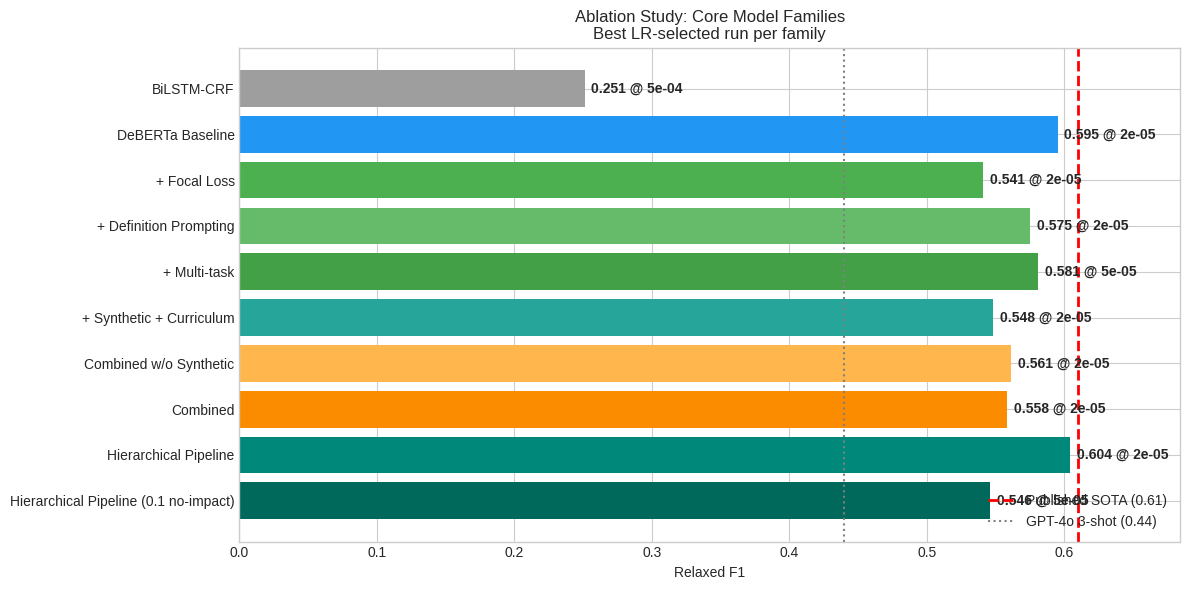

In [ ]:
core_rows = pick_rows(best_rows, CORE_ABLATION_ORDER)
display_rows(
    core_rows,
    columns=['display_name', 'experiment_name', 'lr_display', 'best_relaxed_f1', 'best_dev_loss', 'best_epoch_by_f1'],
)
plot_barh(core_rows, 'Ablation Study: Core Model Families', 'Best LR-selected run per family')


## Advanced Recipe Comparison

These are the higher-cost recipes and multi-seed variants that are useful as soup and ensemble candidates.


,display_name,experiment_name,lr_display,best_relaxed_f1,best_dev_loss,best_epoch_by_f1
0,Recall Boost (seed 42),recall_boost_ow02_s42_lr2em05,2e-05,0.582,0.205525,8
1,Recall Boost (seed 123),recall_boost_ow02_s123_lr2em05,2e-05,0.562,0.228180,8
2,R-Drop (seed 42),rdrop_a1_s42_lr2em05,2e-05,0.577,0.210030,8
3,R-Drop (seed 123),rdrop_a1_s123_lr2em05,2e-05,0.561,0.221584,10
4,FGM + SWA (seed 42),fgm05_swa_s42_lr2em05,2e-05,0.573,0.210184,12


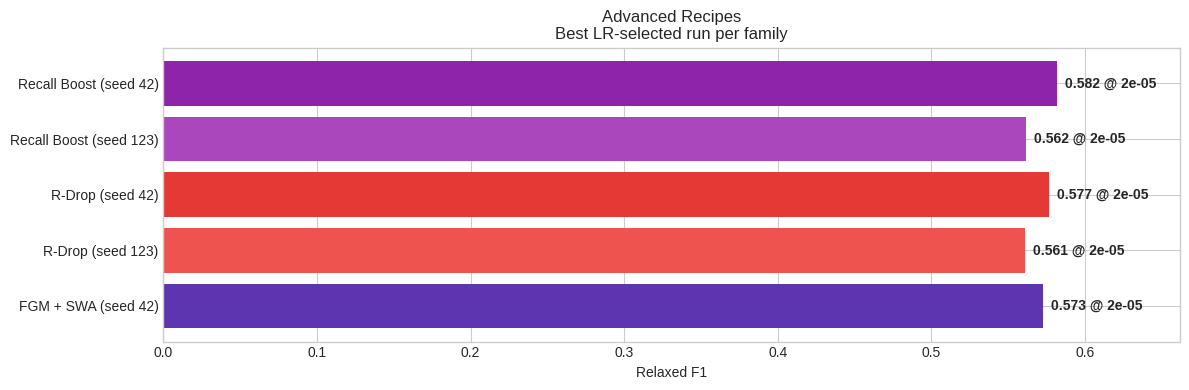

In [ ]:
advanced_rows = pick_rows(best_rows, ADVANCED_ORDER)
display_rows(
    advanced_rows,
    columns=['display_name', 'experiment_name', 'lr_display', 'best_relaxed_f1', 'best_dev_loss', 'best_epoch_by_f1'],
)
plot_barh(advanced_rows, 'Advanced Recipes', 'Best LR-selected run per family', add_reference_lines=False)


## Learning Curves for Best Runs

Use this section to inspect whether the strongest runs are still improving, flattening out, or bouncing in validation loss.


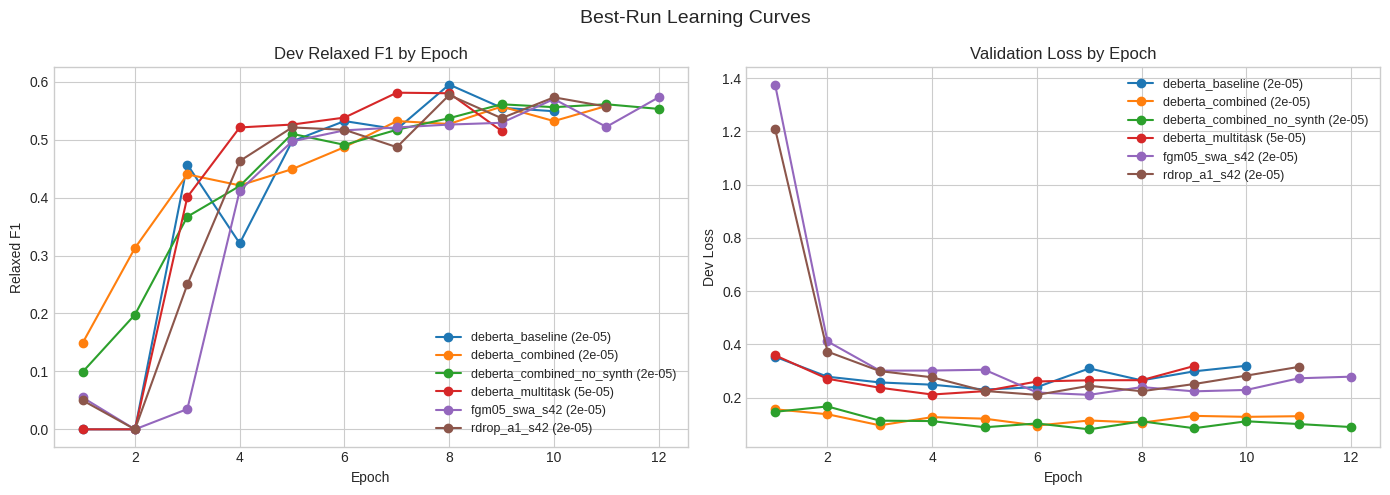

In [ ]:
plot_learning_curves(
    best_rows,
    logs_by_experiment,
    families=[
        'deberta_baseline',
        'deberta_multitask',
        'deberta_combined_no_synth',
        'deberta_combined',
        'rdrop_a1_s42',
        'fgm05_swa_s42',
    ],
    title='Best-Run Learning Curves',
)


## Checkpoint Inventory and Candidate Selection

This is useful for follow-up soup or ensemble work. The table highlights the best families and confirms that top-k checkpoints were saved for them.


In [ ]:
print('Top candidate families sorted by relaxed F1:')
candidate_rows = sort_rows_by_metric(best_rows, 'best_relaxed_f1')
display_rows(
    candidate_rows,
    columns=['family', 'experiment_name', 'lr_display', 'best_relaxed_f1', 'best_strict_f1', 'topk_saved', 'top_checkpoint_path'],
    max_rows=10,
)

print('\nTop candidate families sorted by strict F1:')
candidate_rows_strict = sort_rows_by_metric(best_rows_strict, 'best_strict_f1')
display_rows(
    candidate_rows_strict,
    columns=['family', 'experiment_name', 'lr_display', 'best_relaxed_f1', 'best_strict_f1', 'topk_saved', 'top_checkpoint_path'],
    max_rows=10,
)

best_sources = [row['experiment_name'] for row in candidate_rows[:6]]
print('\nSuggested sources for model soup / ensemble search (relaxed-F1 ranking):')
for source in best_sources:
    print(f'  --source-experiment {source}')


Top candidate families sorted by relaxed F1:


,family,experiment_name,lr_display,best_relaxed_f1,best_strict_f1,topk_saved,top_checkpoint_path
0,hierarchical_deberta,hierarchical_deberta_lr2em05,2e-05,0.604,0.371747,NaN,NaN
1,deberta_baseline,deberta_baseline_lr2em05,2e-05,0.595,0.408759,5.0,/home/ismail/Documents/NLP_assignment/outputs_...
2,recall_boost_ow02_s42,recall_boost_ow02_s42_lr2em05,2e-05,0.582,0.311864,5.0,/home/ismail/Documents/NLP_assignment/outputs_...
3,deberta_multitask,deberta_multitask_lr5em05,5e-05,0.581,0.381625,5.0,/home/ismail/Documents/NLP_assignment/outputs_...
4,rdrop_a1_s42,rdrop_a1_s42_lr2em05,2e-05,0.577,0.337662,5.0,/home/ismail/Documents/NLP_assignment/outputs_...
5,deberta_definition,deberta_definition_lr2em05,2e-05,0.575,0.350168,5.0,/home/ismail/Documents/NLP_assignment/outputs_...
6,fgm05_swa_s42,fgm05_swa_s42_lr2em05,2e-05,0.573,0.355987,5.0,/home/ismail/Documents/NLP_assignment/outputs_...
7,recall_boost_ow02_s123,recall_boost_ow02_s123_lr2em05,2e-05,0.562,0.357388,5.0,/home/ismail/Documents/NLP_assignment/outputs_...
8,deberta_combined_no_synth,deberta_combined_no_synth_lr2em05,2e-05,0.561,0.295858,5.0,/home/ismail/Documents/NLP_assignment/outputs_...
9,rdrop_a1_s123,rdrop_a1_s123_lr2em05,2e-05,0.561,0.360000,5.0,/home/ismail/Documents/NLP_assignment/outputs_...



Top candidate families sorted by strict F1:


,family,experiment_name,lr_display,best_relaxed_f1,best_strict_f1,topk_saved,top_checkpoint_path
0,gliner_finetune,gliner_finetune_lr2em05,2e-05,0.462,0.475771,5.0,/home/ismail/Documents/NLP_assignment/outputs_...
1,hierarchical_deberta_0.1_no_impact,hierarchical_deberta_0.1_no_impact_lr5em05,5e-05,0.546,0.427984,NaN,NaN
2,deberta_definition,deberta_definition_lr5em05,5e-05,0.488,0.422535,5.0,/home/ismail/Documents/NLP_assignment/outputs_...
3,deberta_baseline,deberta_baseline_lr2em05,2e-05,0.595,0.408759,5.0,/home/ismail/Documents/NLP_assignment/outputs_...
4,deberta_multitask,deberta_multitask_lr5em05,5e-05,0.581,0.381625,5.0,/home/ismail/Documents/NLP_assignment/outputs_...
5,deberta_combined,deberta_combined_lr2em05,2e-05,0.558,0.374194,5.0,/home/ismail/Documents/NLP_assignment/outputs_...
6,hierarchical_deberta,hierarchical_deberta_lr2em05,2e-05,0.604,0.371747,NaN,NaN
7,deberta_synthetic_curriculum,deberta_synthetic_curriculum_lr5em05,5e-05,0.529,0.366197,5.0,/home/ismail/Documents/NLP_assignment/outputs_...
8,rdrop_a1_s123,rdrop_a1_s123_lr2em05,2e-05,0.561,0.360000,5.0,/home/ismail/Documents/NLP_assignment/outputs_...
9,recall_boost_ow02_s123,recall_boost_ow02_s123_lr2em05,2e-05,0.562,0.357388,5.0,/home/ismail/Documents/NLP_assignment/outputs_...



Suggested sources for model soup / ensemble search (relaxed-F1 ranking):
  --source-experiment hierarchical_deberta_lr2em05
  --source-experiment deberta_baseline_lr2em05
  --source-experiment recall_boost_ow02_s42_lr2em05
  --source-experiment deberta_multitask_lr5em05
  --source-experiment rdrop_a1_s42_lr2em05
  --source-experiment deberta_definition_lr2em05


## Ensemble Search Results

This section reads any `*_results.json` artifacts produced by `ensemble_search`, summarizes the best overall run, and returns the top 2 combinations for each ensemble size within each vote type.


Ensemble search artifacts sorted by relaxed F1:


,experiment_name,vote_method,candidate_count,total_combinations,best_overall_relaxed_f1,best_overall_strict_f1,best_overall_models
0,ensemble_search_2to5_with_hier,majority_vote,5,26,0.631,0.387543,"deberta_baseline_lr2em05, recall_boost_ow02_s4..."
1,dev_eval_best_ensemble,majority_vote,4,1,0.625,0.380623,"deberta_baseline_lr2em05, recall_boost_ow02_s4..."
2,ensemble_search_2to5,probability_average,7,112,0.614,0.412811,"deberta_baseline_lr2em05, recall_boost_ow02_s4..."



Ensemble search artifacts sorted by strict F1:


,experiment_name,vote_method,candidate_count,total_combinations,best_overall_relaxed_f1,best_overall_strict_f1,best_overall_models
0,ensemble_search_2to5,probability_average,7,112,0.614,0.412811,"deberta_baseline_lr2em05, recall_boost_ow02_s4..."
1,ensemble_search_2to5_with_hier,majority_vote,5,26,0.631,0.387543,"deberta_baseline_lr2em05, recall_boost_ow02_s4..."
2,dev_eval_best_ensemble,majority_vote,4,1,0.625,0.380623,"deberta_baseline_lr2em05, recall_boost_ow02_s4..."



Top ensemble search artifact by relaxed F1: ensemble_search_2to5_with_hier
Combination files: /home/ismail/Documents/NLP_assignment/outputs_new_final_v2/ensemble_search_2to5_with_hier_combinations
Top ensemble search artifact by strict F1: ensemble_search_2to5


,display_name,best_relaxed_f1,best_strict_f1,relaxed_precision,relaxed_recall,models
0,2 models,0.624,0.385135,0.587,0.667,"deberta_baseline_lr2em05, hierarchical_deberta..."
1,3 models,0.625,0.383275,0.640,0.610,"deberta_baseline_lr2em05, recall_boost_ow02_s4..."
2,4 models,0.631,0.387543,0.628,0.633,"deberta_baseline_lr2em05, recall_boost_ow02_s4..."
3,5 models,0.619,0.390411,0.630,0.608,"deberta_baseline_lr2em05, recall_boost_ow02_s4..."


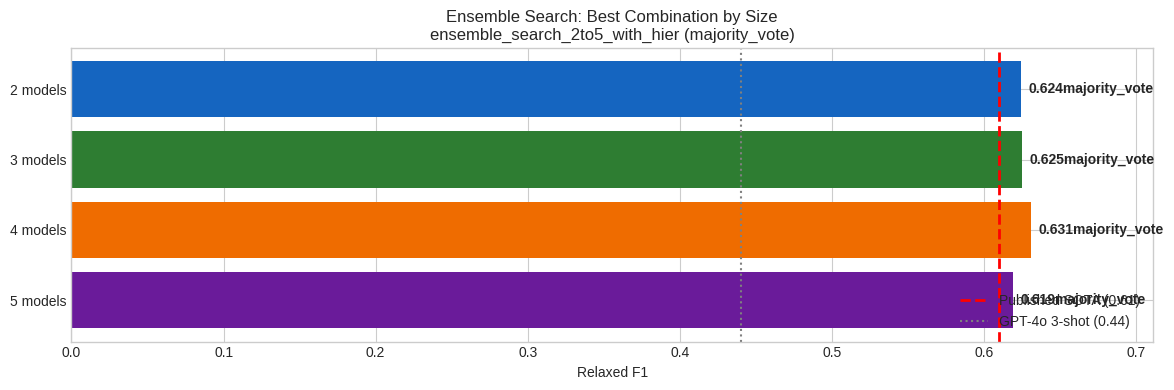


Top 2 combinations for each ensemble size and vote type, sorted by relaxed F1:


,vote_method,num_models,rank_within_group,best_relaxed_f1,best_strict_f1,relaxed_precision,relaxed_recall,ensemble_experiment_name,models
0,majority_vote,4,1,0.631,0.387543,0.628,0.633,ensemble_search_2to5_with_hier,"deberta_baseline_lr2em05, recall_boost_ow02_s4..."
1,majority_vote,3,1,0.625,0.383275,0.640,0.610,ensemble_search_2to5_with_hier,"deberta_baseline_lr2em05, recall_boost_ow02_s4..."
2,majority_vote,4,2,0.625,0.380623,0.624,0.626,dev_eval_best_ensemble,"deberta_baseline_lr2em05, recall_boost_ow02_s4..."
3,majority_vote,2,1,0.624,0.385135,0.587,0.667,ensemble_search_2to5_with_hier,"deberta_baseline_lr2em05, hierarchical_deberta..."
4,majority_vote,3,2,0.621,0.376307,0.643,0.600,ensemble_search_2to5_with_hier,"deberta_baseline_lr2em05, rdrop_a1_s42_lr2em05..."
5,majority_vote,5,1,0.619,0.390411,0.630,0.608,ensemble_search_2to5_with_hier,"deberta_baseline_lr2em05, recall_boost_ow02_s4..."
6,probability_average,3,1,0.614,0.412811,0.656,0.577,ensemble_search_2to5,"deberta_baseline_lr2em05, recall_boost_ow02_s4..."
7,probability_average,4,1,0.612,0.397213,0.635,0.590,ensemble_search_2to5,"deberta_baseline_lr2em05, recall_boost_ow02_s4..."
8,probability_average,3,2,0.610,0.414035,0.637,0.585,ensemble_search_2to5,"deberta_baseline_lr2em05, recall_boost_ow02_s4..."
9,probability_average,5,1,0.610,0.415771,0.644,0.579,ensemble_search_2to5,"deberta_baseline_lr2em05, deberta_multitask_lr..."



Top 2 combinations for each ensemble size and vote type, sorted by strict F1:


,vote_method,num_models,rank_within_group,best_relaxed_f1,best_strict_f1,relaxed_precision,relaxed_recall,ensemble_experiment_name,models
0,probability_average,2,2,0.606,0.431095,0.652,0.567,ensemble_search_2to5,"deberta_baseline_lr2em05, rdrop_a1_s42_lr2em05"
1,probability_average,5,1,0.610,0.415771,0.644,0.579,ensemble_search_2to5,"deberta_baseline_lr2em05, deberta_multitask_lr..."
2,probability_average,3,2,0.610,0.414035,0.637,0.585,ensemble_search_2to5,"deberta_baseline_lr2em05, recall_boost_ow02_s4..."
3,probability_average,2,1,0.606,0.412811,0.639,0.577,ensemble_search_2to5,"deberta_baseline_lr2em05, recall_boost_ow02_s4..."
4,probability_average,3,1,0.614,0.412811,0.656,0.577,ensemble_search_2to5,"deberta_baseline_lr2em05, recall_boost_ow02_s4..."
5,probability_average,5,2,0.610,0.411150,0.644,0.579,ensemble_search_2to5,"deberta_baseline_lr2em05, recall_boost_ow02_s4..."
6,probability_average,4,2,0.609,0.398601,0.645,0.577,ensemble_search_2to5,"deberta_baseline_lr2em05, recall_boost_ow02_s4..."
7,probability_average,4,1,0.612,0.397213,0.635,0.590,ensemble_search_2to5,"deberta_baseline_lr2em05, recall_boost_ow02_s4..."
8,majority_vote,5,1,0.619,0.390411,0.630,0.608,ensemble_search_2to5_with_hier,"deberta_baseline_lr2em05, recall_boost_ow02_s4..."
9,majority_vote,4,1,0.631,0.387543,0.628,0.633,ensemble_search_2to5_with_hier,"deberta_baseline_lr2em05, recall_boost_ow02_s4..."


In [ ]:
if ensemble_rows:
    print('Ensemble search artifacts sorted by relaxed F1:')
    display_rows(
        ensemble_rows_relaxed,
        columns=[
            'experiment_name',
            'vote_method',
            'candidate_count',
            'total_combinations',
            'best_overall_relaxed_f1',
            'best_overall_strict_f1',
            'best_overall_models',
        ],
    )

    print('\nEnsemble search artifacts sorted by strict F1:')
    display_rows(
        ensemble_rows_strict,
        columns=[
            'experiment_name',
            'vote_method',
            'candidate_count',
            'total_combinations',
            'best_overall_relaxed_f1',
            'best_overall_strict_f1',
            'best_overall_models',
        ],
    )

    best_ensemble_run = ensemble_rows_relaxed[0]
    best_ensemble_run_strict = ensemble_rows_strict[0]
    print(f"\nTop ensemble search artifact by relaxed F1: {best_ensemble_run['experiment_name']}")
    print(f"Combination files: {best_ensemble_run.get('combination_results_dir') or 'not saved'}")
    print(f"Top ensemble search artifact by strict F1: {best_ensemble_run_strict['experiment_name']}")

    selected_ensemble_rows = [
        row for row in ensemble_best_by_size_rows
        if row['ensemble_experiment_name'] == best_ensemble_run['experiment_name']
    ]
    display_rows(
        selected_ensemble_rows,
        columns=[
            'display_name',
            'best_relaxed_f1',
            'best_strict_f1',
            'relaxed_precision',
            'relaxed_recall',
            'models',
        ],
    )
    plot_barh(
        selected_ensemble_rows,
        'Ensemble Search: Best Combination by Size',
        f"{best_ensemble_run['experiment_name']} ({best_ensemble_run['vote_method']})",
        add_reference_lines=True,
    )

    print('\nTop 2 combinations for each ensemble size and vote type, sorted by relaxed F1:')
    display_rows(
        ensemble_top_two_rows,
        columns=[
            'vote_method',
            'num_models',
            'rank_within_group',
            'best_relaxed_f1',
            'best_strict_f1',
            'relaxed_precision',
            'relaxed_recall',
            'ensemble_experiment_name',
            'models',
        ],
        sort_by='best_relaxed_f1',
    )

    print('\nTop 2 combinations for each ensemble size and vote type, sorted by strict F1:')
    display_rows(
        ensemble_top_two_rows,
        columns=[
            'vote_method',
            'num_models',
            'rank_within_group',
            'best_relaxed_f1',
            'best_strict_f1',
            'relaxed_precision',
            'relaxed_recall',
            'ensemble_experiment_name',
            'models',
        ],
        sort_by='best_strict_f1',
    )
else:
    print('No ensemble search artifacts found in OUTPUT_DIR.')


## Model Soup Results

This section reads any `*_soup_results.json` artifacts in `OUTPUT_DIR`, ranks the soups, and highlights the strongest soup for each model type. Because it keys off `OUTPUT_DIR`, it works for both clean and non-clean runs.


Best soup per model type selected by relaxed F1:


,model_type,experiment_name,best_relaxed_f1,best_strict_f1,relaxed_precision,relaxed_recall,num_checkpoints,source_experiments
0,deberta_multitask,recall_boost_ow02_s42_lr2em05_soup,0.595,0.331126,0.582,0.608,3,recall_boost_ow02_s42_lr2em05
1,deberta,deberta_baseline_lr2em05_soup,0.589,0.436090,0.692,0.513,3,deberta_baseline_lr2em05



Best soup per model type selected by strict F1:


,model_type,experiment_name,best_relaxed_f1,best_strict_f1,relaxed_precision,relaxed_recall,num_checkpoints,source_experiments
0,deberta,deberta_baseline_lr2em05_soup,0.589,0.436090,0.692,0.513,3,deberta_baseline_lr2em05
1,deberta_multitask,rdrop_a1_s123_lr2em05_soup,0.557,0.401361,0.592,0.526,3,rdrop_a1_s123_lr2em05



Top ranked model soups by relaxed F1:


,experiment_name,model_type,best_relaxed_f1,best_strict_f1,num_checkpoints,num_source_experiments,source_experiments
0,recall_boost_ow02_s42_lr2em05_soup,deberta_multitask,0.595,0.331126,3,1,recall_boost_ow02_s42_lr2em05
1,deberta_baseline_lr2em05_soup,deberta,0.589,0.436090,3,1,deberta_baseline_lr2em05
2,fgm05_swa_s42_lr2em05_soup,deberta_multitask,0.581,0.368601,3,1,fgm05_swa_s42_lr2em05
3,rdrop_a1_s42_lr2em05_soup,deberta_multitask,0.579,0.379661,3,1,rdrop_a1_s42_lr2em05
4,deberta_multitask_lr5em05_soup,deberta_multitask,0.574,0.387543,3,1,deberta_multitask_lr5em05
5,rdrop_a1_s123_lr5em05_soup,deberta_multitask,0.573,0.396104,3,1,rdrop_a1_s123_lr5em05
6,rdrop_a1_s42_lr5em05_soup,deberta_multitask,0.571,0.359477,3,1,rdrop_a1_s42_lr5em05
7,recall_boost_ow02_s123_lr2em05_soup,deberta_multitask,0.561,0.338762,3,1,recall_boost_ow02_s123_lr2em05
8,rdrop_a1_s123_lr2em05_soup,deberta_multitask,0.557,0.401361,3,1,rdrop_a1_s123_lr2em05
9,recall_boost_ow02_s123_lr5em05_soup,deberta_multitask,0.557,0.352941,3,1,recall_boost_ow02_s123_lr5em05



Top ranked model soups by strict F1:


,experiment_name,model_type,best_relaxed_f1,best_strict_f1,num_checkpoints,num_source_experiments,source_experiments
0,deberta_baseline_lr2em05_soup,deberta,0.589,0.436090,3,1,deberta_baseline_lr2em05
1,deberta_synthetic_curriculum_lr5em05_soup,deberta,0.548,0.402930,3,1,deberta_synthetic_curriculum_lr5em05
2,rdrop_a1_s123_lr2em05_soup,deberta_multitask,0.557,0.401361,3,1,rdrop_a1_s123_lr2em05
3,rdrop_a1_s123_lr5em05_soup,deberta_multitask,0.573,0.396104,3,1,rdrop_a1_s123_lr5em05
4,recall_boost_ow02_s42_lr5em05_soup,deberta_multitask,0.545,0.395833,3,1,recall_boost_ow02_s42_lr5em05
5,deberta_multitask_lr5em05_soup,deberta_multitask,0.574,0.387543,3,1,deberta_multitask_lr5em05
6,fgm05_swa_s42_lr5em05_soup,deberta_multitask,0.545,0.384880,3,1,fgm05_swa_s42_lr5em05
7,rdrop_a1_s42_lr2em05_soup,deberta_multitask,0.579,0.379661,3,1,rdrop_a1_s42_lr2em05
8,fgm05_swa_s42_lr2em05_soup,deberta_multitask,0.581,0.368601,3,1,fgm05_swa_s42_lr2em05
9,rdrop_a1_s42_lr0p0005_soup,deberta_multitask,0.494,0.363636,3,1,rdrop_a1_s42_lr0p0005


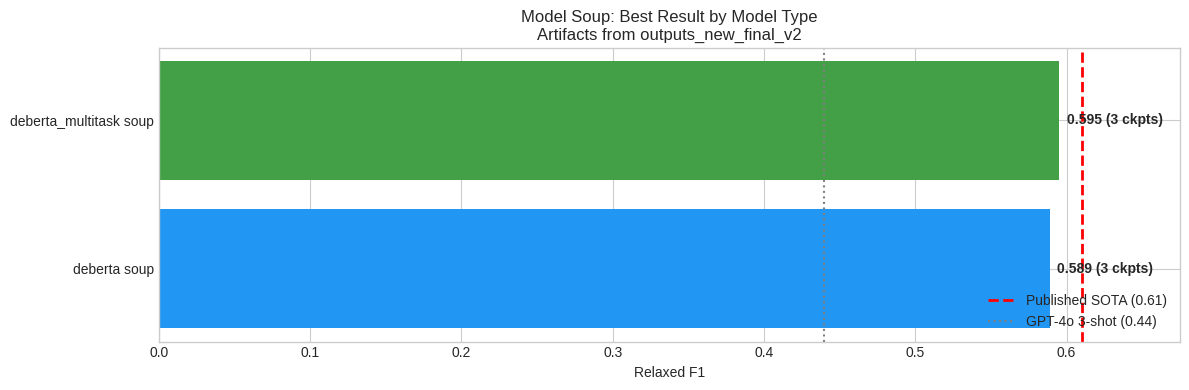

In [ ]:
if soup_rows:
    print('Best soup per model type selected by relaxed F1:')
    display_rows(
        best_soup_rows,
        columns=[
            'model_type',
            'experiment_name',
            'best_relaxed_f1',
            'best_strict_f1',
            'relaxed_precision',
            'relaxed_recall',
            'num_checkpoints',
            'source_experiments',
        ],
    )

    print('\nBest soup per model type selected by strict F1:')
    display_rows(
        sort_rows_by_metric(best_soup_rows_strict, 'best_strict_f1'),
        columns=[
            'model_type',
            'experiment_name',
            'best_relaxed_f1',
            'best_strict_f1',
            'relaxed_precision',
            'relaxed_recall',
            'num_checkpoints',
            'source_experiments',
        ],
    )

    print('\nTop ranked model soups by relaxed F1:')
    display_rows(
        soup_rows,
        columns=[
            'experiment_name',
            'model_type',
            'best_relaxed_f1',
            'best_strict_f1',
            'num_checkpoints',
            'num_source_experiments',
            'source_experiments',
        ],
        max_rows=20,
    )

    print('\nTop ranked model soups by strict F1:')
    display_rows(
        soup_rows,
        columns=[
            'experiment_name',
            'model_type',
            'best_relaxed_f1',
            'best_strict_f1',
            'num_checkpoints',
            'num_source_experiments',
            'source_experiments',
        ],
        sort_by='best_strict_f1',
        max_rows=20,
    )

    soup_plot_rows = []
    for row in best_soup_rows:
        plot_row = dict(row)
        plot_row['family'] = row['model_type']
        plot_row['display_name'] = f"{row['model_type']} soup"
        plot_row['annotation_label'] = f" ({row['num_checkpoints']} ckpts)"
        soup_plot_rows.append(plot_row)

    plot_barh(
        soup_plot_rows,
        'Model Soup: Best Result by Model Type',
        f"Artifacts from {OUTPUT_DIR.name}",
        add_reference_lines=True,
    )
else:
    print('No model soup artifacts found in OUTPUT_DIR.')


## Notes

- This notebook only uses artifacts present in `OUTPUT_DIR`.
- If GLiNER or hierarchical runs were executed in a different output folder, point `OUTPUT_DIR` there and rerun the notebook.
- Ensemble sections appear automatically when `ensemble_search` result files are present in `OUTPUT_DIR`.
- Model soup sections appear automatically when `*_soup_results.json` files are present in `OUTPUT_DIR`.
- The sweep in `outputs_new_final_v2` currently contains the finished runs in that directory, so the plots only reflect artifacts that actually exist there.
